In [13]:
import os
import re

import matplotlib.pyplot as plt
import pandas as pd


In [14]:
STAT_PATH = "../experiments"
TASK_DYNAMIC_NAME = os.path.join("exp", "task_dynamic")
PARAMS_NAME = "parameters.xml"
EXP_NAME = "run_"


In [15]:
def read_replication_value(params_path):
    with open(params_path, "r", encoding="utf-8") as file:
        content = file.read()

    matches = re.findall(r"<target_nresults>\s*([0-9]+)\s*</target_nresults>", content)
    if not matches:
        return None

    return int(matches[0])


def load_valid_series(file_path):
    raw = pd.read_csv(file_path, sep=r"\s+", header=None)

    if raw.shape[1] == 1:
        df = raw.rename(columns={0: "valid_delta"})
        df["second"] = df.index
    else:
        df = raw.iloc[:, :2].copy()
        df.columns = ["application", "valid_delta"]
        df["application"] = df["application"].astype(int)
        df["second"] = df.groupby("application").cumcount()
        df = df.groupby("second", as_index=False)["valid_delta"].sum()

    df["valid_workunits"] = df["valid_delta"].cumsum()
    df["time_hours"] = df["second"] / 3600.0
    return df


def plot_valid_workunits(ax, df, label):
    ax.plot(df["time_hours"], df["valid_workunits"], label=label)
    ax.set_title("Количество валидных воркюнитов от времени")
    ax.set_xlabel("Время, ч")
    ax.set_ylabel("Количество валидных воркюнитов, ед")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)


found ['run_0001', 'run_0003', 'run_0004', 'run_0005']


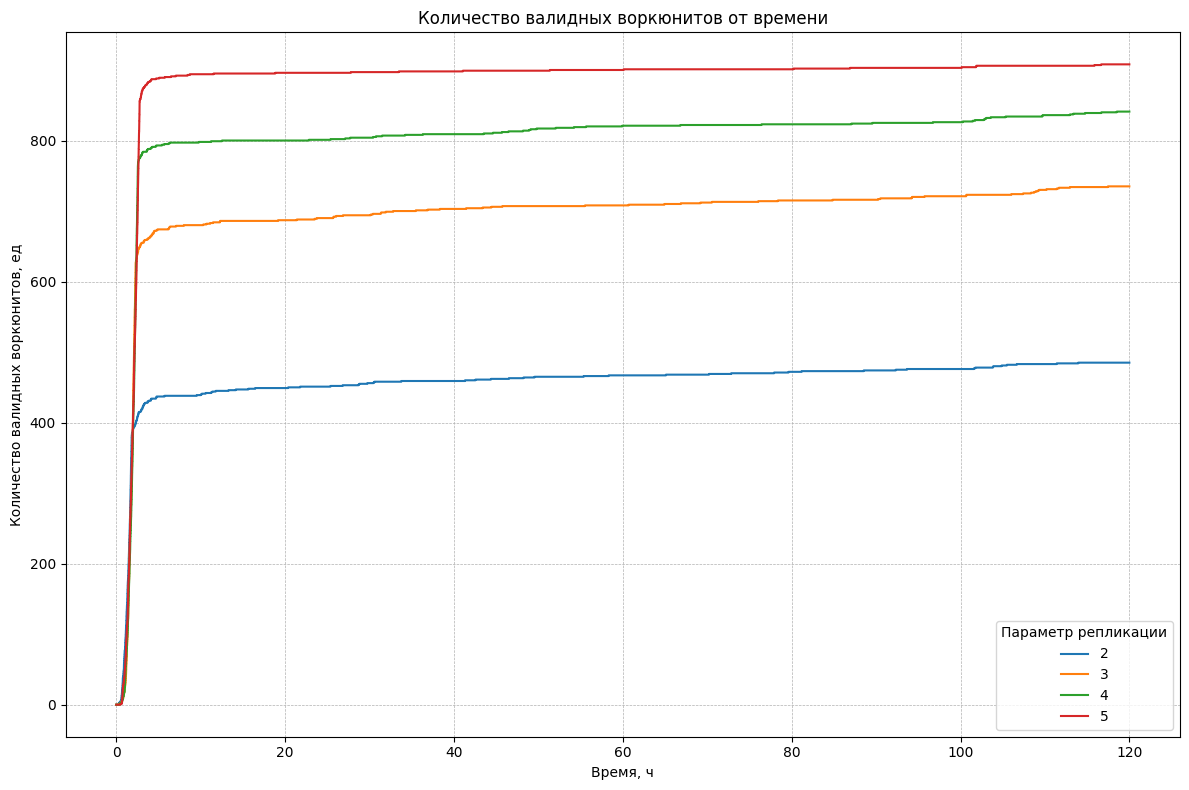

In [16]:
folders = sorted(
    folder
    for folder in os.listdir(STAT_PATH)
    if os.path.isdir(os.path.join(STAT_PATH, folder)) and folder.startswith(EXP_NAME)
)

if not folders:
    print(f"there is no folders in {STAT_PATH}")
else:
    print(f"found {folders}")

datasets = []

for folder in folders:
    full_path = os.path.join(STAT_PATH, folder)
    task_dynamic_path = os.path.join(full_path, TASK_DYNAMIC_NAME)
    params_path = os.path.join(full_path, PARAMS_NAME)

    if not os.path.exists(task_dynamic_path):
        print(f"skip {folder}: {TASK_DYNAMIC_NAME} not found")
        continue

    if not os.path.exists(params_path):
        print(f"skip {folder}: {PARAMS_NAME} not found")
        continue

    replication_value = read_replication_value(params_path)
    if replication_value is None:
        print(f"skip {folder}: target_nresults not found")
        continue

    datasets.append((replication_value, folder, load_valid_series(task_dynamic_path)))

if not datasets:
    print("there is no valid workunits data to plot")
else:
    datasets.sort(key=lambda item: (item[0], item[1]))
    counts_by_replication = {}
    for replication_value, folder, df in datasets:
        counts_by_replication[replication_value] = counts_by_replication.get(replication_value, 0) + 1

    fig, ax = plt.subplots(figsize=(12, 8))

    for replication_value, folder, df in datasets:
        label = str(replication_value)
        if counts_by_replication[replication_value] > 1:
            label = f"{replication_value} ({folder})"
        plot_valid_workunits(ax, df, label)

    ax.legend(title="Параметр репликации")
    plt.tight_layout()
    plt.show()
